In [1]:
from google.colab import drive
drive.mount('/content/drive/')

# set drive/MyDrive/ ad base working directory
%cd /content/drive/MyDrive/dse-ml-2026/materials/2026-09-23_wednesday/09_toller_clustering



Mounted at /content/drive/
/content/drive/MyDrive/dse-ml-2026/materials/2026-09-23_wednesday/09_toller_clustering


## Task 1: Getting to know the algorithms

The goal of the first task is to explore the algorithms, run them on a simple dataset, and then find out what are good values for their parameters

In [2]:
#Task 1.1: Import and load the dataset. Please run this cell
import pandas as pd
import numpy as np

twty = np.array(pd.read_table("twty",header=None,sep=","))

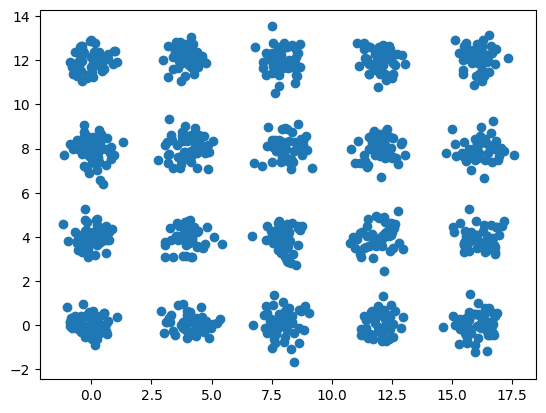

In [3]:
#Task 1.2: Visualize the dataset to get an understanding. Please run this cell.
import matplotlib.pyplot as plt

plt.scatter(twty[:,0],twty[:,1])
plt.show()

In [4]:
#Task 1.3: How many clusters do you see?
number_of_clusters = 20

In [7]:
#Task 1.4: Run k-means on the dataset. Please re-use and adjust the code snippet below as needed.

from sklearn.cluster import KMeans

#You can run k-means like this:
kmeans = KMeans(n_clusters=20).fit(twty)
labels = kmeans.labels_
cluster_centers = kmeans.cluster_centers_


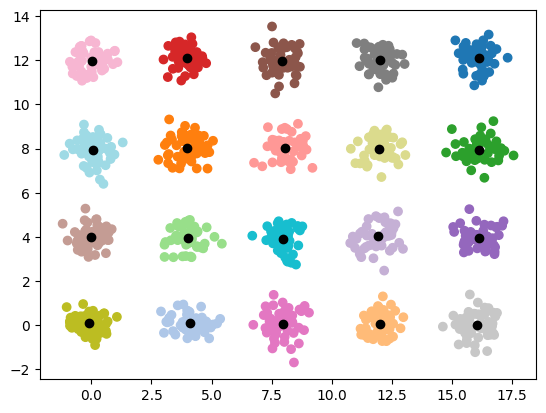

In [8]:
#Task 1.5: Visualize the clustering. Please run this cell. If you did everything right, you should see a successful clustering.
#If it does not look right, go back to Task 1.3
def cmap(labels):
    m = plt.get_cmap('tab20')
    colors = np.array([
    'black' if label == -1 else m(label)
    for label in labels
    ],dtype=object)
    return colors

plt.scatter(twty[:,0],twty[:,1],c=cmap(labels))
plt.scatter(cluster_centers[:,0],cluster_centers[:,1],c='k')
plt.show()

In [55]:
#Task 1.6: Run HAC. You will need to select reasonable hyperparameters.
from sklearn.cluster import AgglomerativeClustering

hac = AgglomerativeClustering(
    #n_clusters=21,
    #metric='euclidean',
    #linkage='ward'
)
labels_hac=hac.fit_predict(twty)



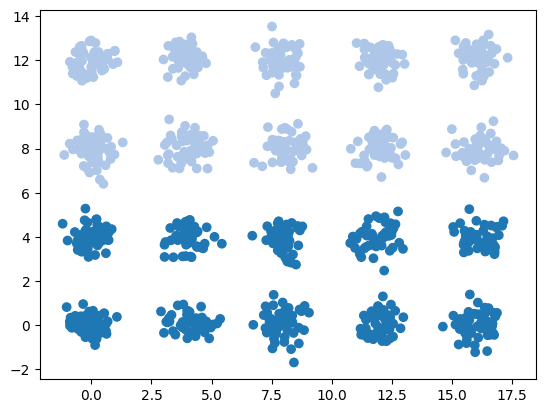

In [56]:
#Task 1.7: Visualize the clustering. Please run this cell. If you did everything right, you should see a successful clustering.
#If it does not look right, go back to Task 1.6
plt.scatter(twty[:,0],twty[:,1],c=cmap(labels_hac))
plt.show()

In [47]:
#Task 1.8 Run DBSCAN. You will need to select reasonable values for eps and min_samples
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5,min_samples=10)
labels_dbscan = dbscan.fit_predict(twty)

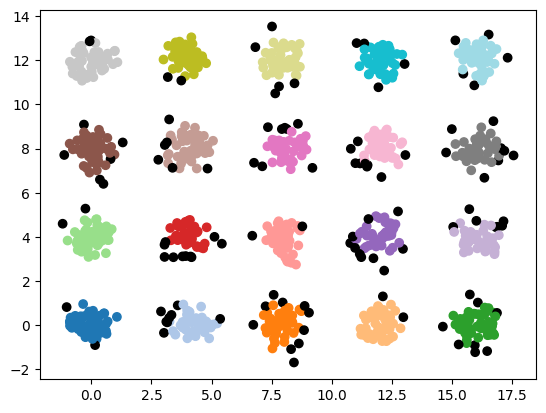

In [48]:
#Task 1.9 Visualize the clustering. Please run this cell. If you did everything right, you should see a successful clustering.
#If it does not look right, go back to Task 1.8
plt.scatter(twty[:,0],twty[:,1],c=cmap(labels_dbscan))
plt.show()

## Task 2: Cluster a dataset on your own

In [49]:
#Task 2.1: Load the CoCo dataset. Please run this cell
coco = np.array(pd.read_table("coco",header=None,sep=" "))

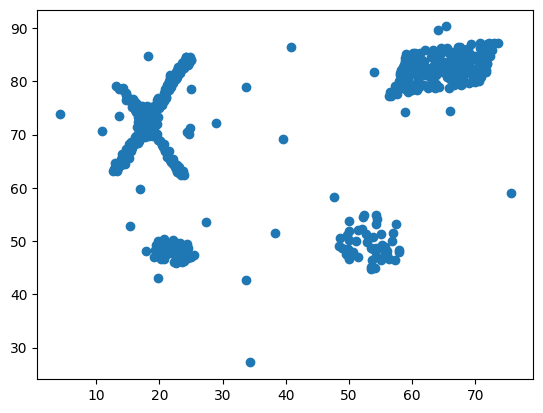

In [50]:
#Task 2.2: Visualize the dataset to understand what you're dealing with. Fill in the missing code.
#You should see four clusters and a few outliers
import matplotlib.pyplot as plt

plt.scatter(coco[:,0], coco[:,1])
plt.show()

In [51]:
#Task 2.3: Run either K-means, HAC, or DBSCAN on coco. Try to set meaningful parameters.
#k-means
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4).fit(coco)
labels = kmeans.labels_
cluster_centers = kmeans.cluster_centers_


In [64]:
#hac
from sklearn.cluster import AgglomerativeClustering
hac_coco = AgglomerativeClustering(n_clusters = 4).fit(coco)
labels_hac_coco = hac_coco.labels_

In [62]:
#DBSCAN
from sklearn.cluster import DBSCAN
dbscan_coco = DBSCAN().fit(coco)
labels_dbscan_coco = dbscan_coco.labels_

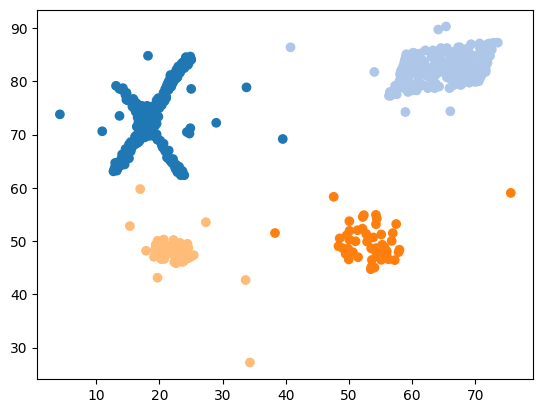

In [65]:
#Task 2.4 Visualize the clustering. Please run this cell, but fill in your labels. If you did everything right, you should see a successful clustering.
#Your clustering is successful if it clearly separates the four clusters from each other, and does not include (too many) outliers.
#If it does not look right, go back to Task 2.3
plt.scatter(coco[:,0],coco[:,1],c=cmap(labels))
plt.show()

## Task 3: Finding two clusters in Old Faithful

In [66]:
#Task 3.1: Load old faithful. Please run this cell.
faithful = np.array(pd.read_table("faithful",header=None,sep=","))

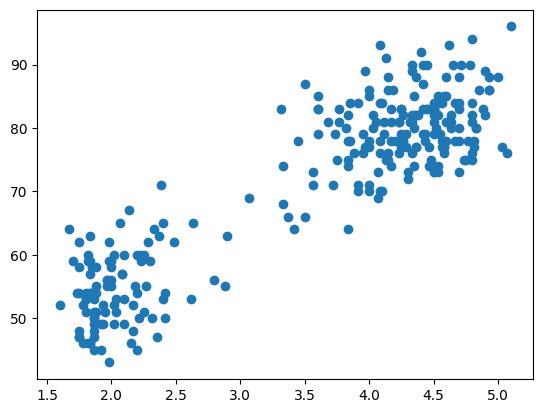

In [67]:
#Task 3.2: Visualize the dataset to understand what you're dealing with. Fill in the missing code.
import matplotlib.pyplot as plt
plt.scatter(faithful[:,0], faithful[:,1])
plt.show()

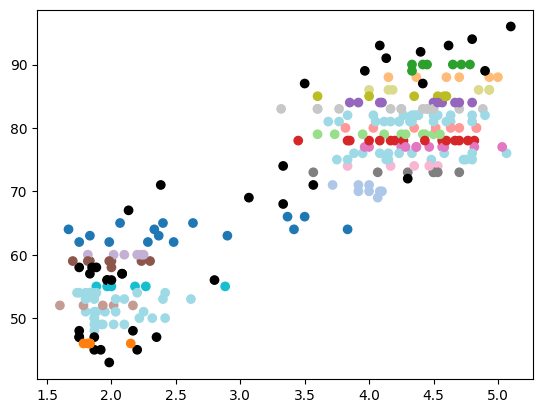

In [70]:
#Task 3.3: Try out HDBSCAN and visualize the results. Please run this cell.
from sklearn.cluster import HDBSCAN
b = HDBSCAN().fit(faithful)
b_labels= b.labels_
plt.scatter(faithful[:,0],faithful[:,1],c=cmap(b_labels))
plt.show()

In [ ]:
#Task 3.4: Is this a good result? If yes, why? If not, why not? Write your answer in the cell below.

In [77]:
#Task 3.3: Cluster Old Faithful and check the results using an appropriate visualization. Write your own code.
#Repeat this task until you obtain a satisfactory clustering
#kmeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3).fit(faithful)
labels = kmeans.labels_
cluster_centers = kmeans.cluster_centers_


In [84]:
#hac
from sklearn.cluster import AgglomerativeClustering
hac = AgglomerativeClustering(n_clusters=3).fit(faithful)
labels = hac.labels_

In [88]:
#DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=2,min_samples=2).fit(faithful)
labels = dbscan.labels_

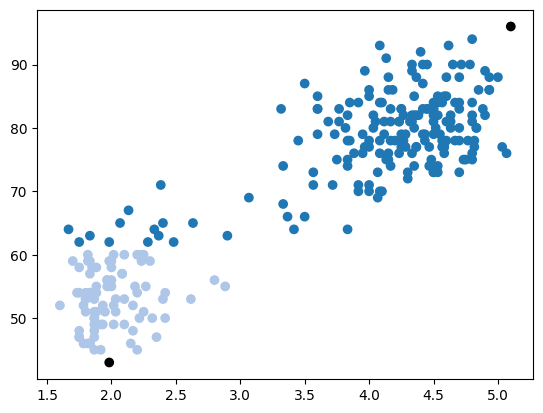

In [89]:
#visualization of faithful
plt.scatter(faithful[:,0],faithful[:,1],c=cmap(labels))
plt.show()

## Task 4: Cluster a word embedding

In [90]:
#Task 4.1: Load the word embedding and check that it loaded correctly. Please run this cell

embeddings = pd.read_pickle("SENTENCE_TRANSFORMER_SMALL_PER_UTTERANCE.pkl")
print(embeddings.head())

                        Parent_ID  \
0   ParlaMint-IS_2022-01-17-20.u1   
1  ParlaMint-IS_2022-01-17-20.u10   
2  ParlaMint-IS_2022-01-17-20.u11   
3  ParlaMint-IS_2022-01-17-20.u12   
4  ParlaMint-IS_2022-01-17-20.u13   

                                                Text  \
0  President of the United States reports: I have...   
1  Before the weekend, an article by Stefánssonar...   
2  I read this decision in Perconte, which is not...   
3  In fact, this is shown in the letter quoted by...   
4  Yes, that's right. That's right. A senator who...   

                                           embedding  
0  [-0.051902045, -0.1029595, 0.06313952, 0.02980...  
1  [-0.104611516, 0.06670187, -0.0565696, -0.0242...  
2  [-0.003742227, 0.07299825, -0.017051963, -0.02...  
3  [-0.10630381, 0.06314152, -0.014823501, 0.0141...  
4  [-0.037640795, 0.1038077, -0.061545677, 0.0093...  


In [91]:
#Task 4.2: Extract the vectors and normalize them. Please run this cell
from sklearn.preprocessing import normalize
df = normalize(np.stack(embeddings.embedding.values))

In [92]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 3.2 MB/s eta 0:00:00


In [93]:
#Task 4.3: Use UMAP to reduce the embedding to two components. Write your own code.
import umap
reducer = umap.UMAP(n_components=2)
embedding = reducer.fit_transform(df)


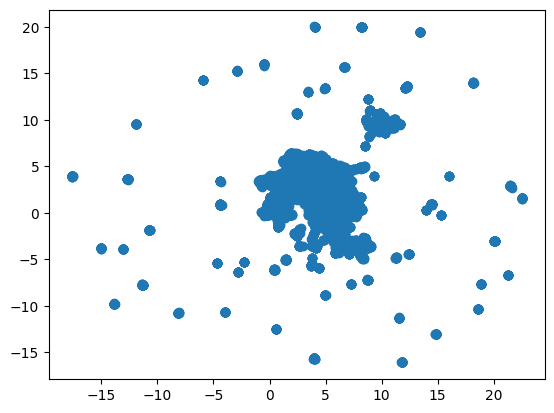

In [94]:
#Task 4.4: Plot the dataset. Write your own code.
plt.scatter(embedding[:,0],embedding[:,1])
plt.show()

In [100]:
#Task 4.5: Cluster the reduced dataset, visuallize the results, and check.
#Write your own code
#You may need to repeat this task several times to obtain a satisfactory clustering
#Aim for 5-10 clusters.
#kmeans
kmeans = KMeans(n_clusters=4).fit_predict(embedding)


In [102]:
#hac
hac = AgglomerativeClustering().fit_predict(embedding)

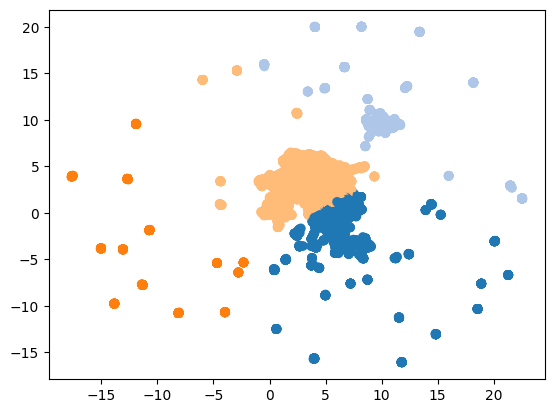

In [101]:
#visualization of embeddings
plt.scatter(embedding[:,0],embedding[:,1],c=cmap(kmeans))
plt.show()

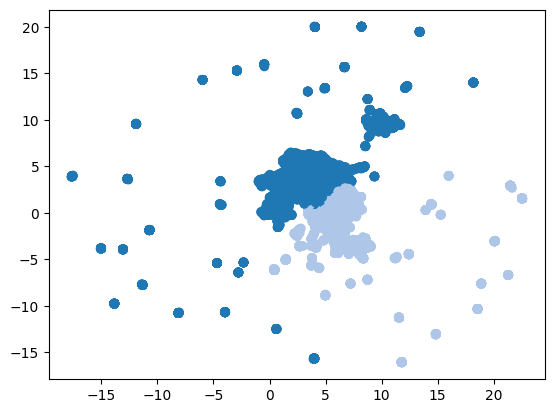

In [103]:
plt.scatter(embedding[:,0],embedding[:,1],c=cmap(hac))
plt.show()